# Student Performance Prediction System
### Minor Project | Machine Learning | Python

---
**Objective:** Predict whether a student will Pass or Fail based on study habits and academic history.

**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Models Used:** Logistic Regression, Decision Tree, Random Forest, Naive Bayes

---

## Step 1 — Install & Import Libraries

In [1]:
# All libraries come pre-installed in Google Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2 — Load Dataset

> **How to use:** Upload `student_dataset.csv` using the cell below, OR the dataset is auto-created inline.

In [16]:
import io

#──  Upload your CSV file ───
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))


Saving student_dataset.csv to student_dataset (1).csv


## Step 3 — Data Preprocessing

In [18]:
print(" Dataset Info:")
print(f"  Shape        : {df.shape}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Class Balance:")
print(df['Final_Result'].value_counts())
print()

# Encode target: Pass=1, Fail=0
le = LabelEncoder()
df['Result_Encoded'] = le.fit_transform(df['Final_Result'])
print(f"  Encoding → Fail=0, Pass=1")

print()
print(" Basic Statistics:")
df[['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks']].describe().round(2)

 Dataset Info:
  Shape        : (60, 8)
  Missing Values: 0
  Class Balance:
Final_Result
Pass    36
Fail    24
Name: count, dtype: int64

  Encoding → Fail=0, Pass=1

 Basic Statistics:


,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks
count,60.00,60.00,60.00,60.00,60.00
mean,4.25,68.50,60.45,64.02,61.02
std,2.18,18.52,20.35,21.04,18.75
min,1.00,35.00,27.00,28.00,29.00
25%,2.00,52.00,41.50,47.00,44.75
50%,4.00,70.50,61.50,65.00,62.50
75%,6.00,85.00,77.25,82.00,76.00
max,8.00,96.00,93.00,96.00,91.00


## Step 4 — Exploratory Data Analysis (EDA)

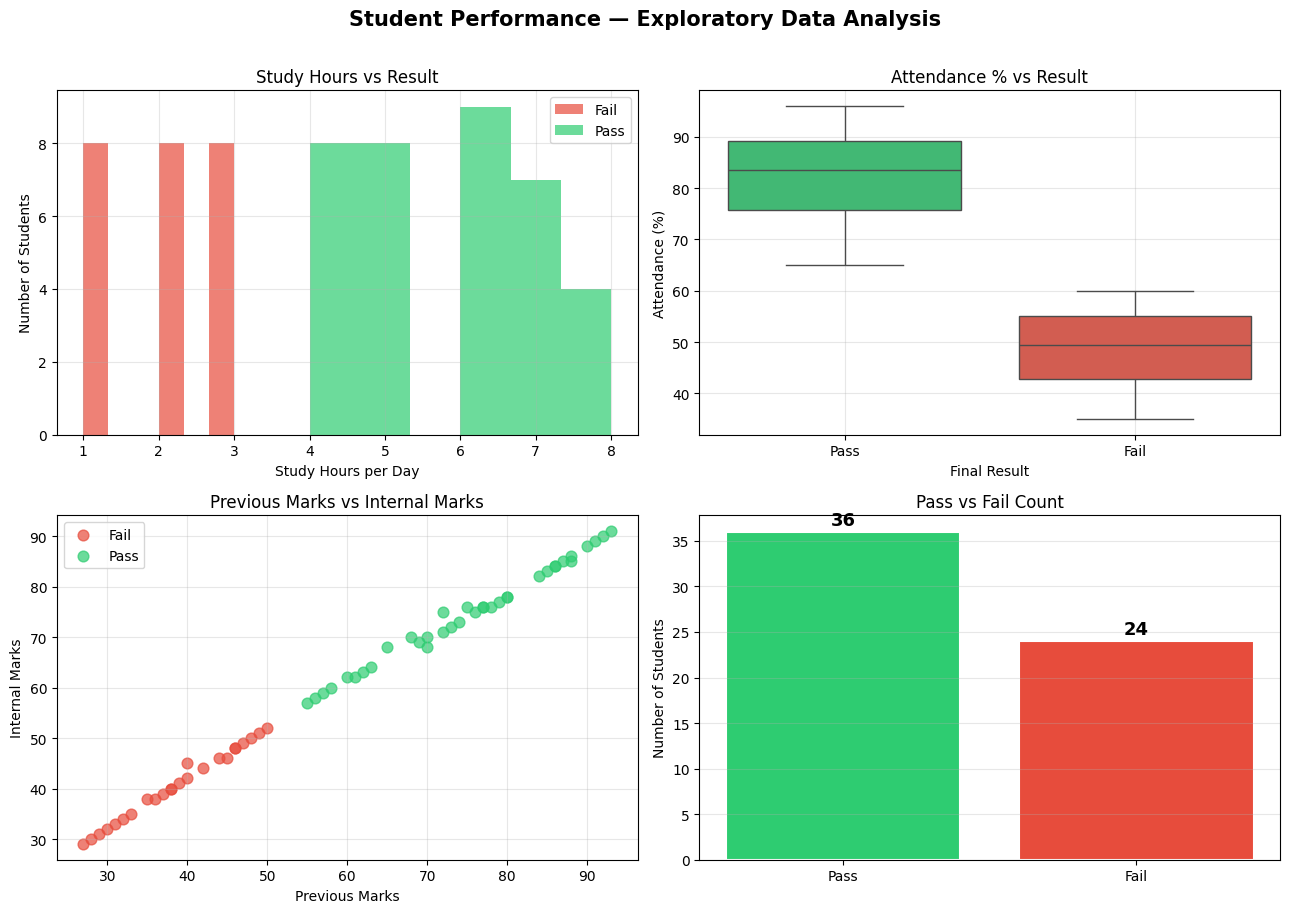

✅ EDA Plots Generated


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Student Performance — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

colors = {'Pass': '#2ecc71', 'Fail': '#e74c3c'}

# Plot 1: Study Hours vs Final Result
ax1 = axes[0, 0]
for result, grp in df.groupby('Final_Result'):
    ax1.hist(grp['Study_Hours'], label=result, alpha=0.7, bins=6, color=colors[result])
ax1.set_title('Study Hours vs Result')
ax1.set_xlabel('Study Hours per Day')
ax1.set_ylabel('Number of Students')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Attendance vs Final Result
ax2 = axes[0, 1]
sns.boxplot(x='Final_Result', y='Attendance', data=df,
            palette=colors, ax=ax2)
ax2.set_title('Attendance % vs Result')
ax2.set_xlabel('Final Result')
ax2.set_ylabel('Attendance (%)')
ax2.grid(alpha=0.3)

# Plot 3: Previous Marks vs Internal Marks (scatter)
ax3 = axes[1, 0]
for result, grp in df.groupby('Final_Result'):
    ax3.scatter(grp['Previous_Marks'], grp['Internal_Marks'],
                label=result, alpha=0.7, s=60, color=colors[result])
ax3.set_title('Previous Marks vs Internal Marks')
ax3.set_xlabel('Previous Marks')
ax3.set_ylabel('Internal Marks')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Pass/Fail count
ax4 = axes[1, 1]
result_counts = df['Final_Result'].value_counts()
bars = ax4.bar(result_counts.index, result_counts.values,
               color=[colors[r] for r in result_counts.index], edgecolor='white', linewidth=1.5)
for bar in bars:
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold', fontsize=13)
ax4.set_title('Pass vs Fail Count')
ax4.set_ylabel('Number of Students')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✅ EDA Plots Generated")

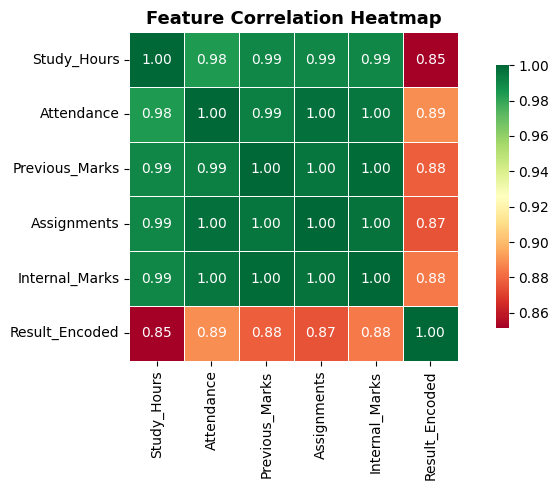

✅ Correlation heatmap shows which features most affect the result


In [20]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
corr_cols = ['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks','Result_Encoded']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap shows which features most affect the result")

##  Step 5 — Feature Selection & Train-Test Split

In [6]:
# Select features (X) and target (y)
features = ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']
X = df[features]
y = df['Result_Encoded']   # 0 = Fail, 1 = Pass

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Feature Selection Done")
print(f"   Features used : {features}")
print(f"   Training set  : {X_train.shape[0]} samples (80%)")
print(f"   Testing set   : {X_test.shape[0]} samples (20%)")

✅ Feature Selection Done
   Features used : ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']
   Training set  : 48 samples (80%)
   Testing set   : 12 samples (20%)


## Step 6 — Model Training & Evaluation

We train **4 models** and compare their performance.

In [21]:
# Define all models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    'Naive Bayes'         : GaussianNB()
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(" Model Comparison Results:")
print()
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

 Model Comparison Results:

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    1.0000     1.0000  1.0000    1.0000
      Decision Tree    1.0000     1.0000  1.0000    1.0000
      Random Forest    1.0000     1.0000  1.0000    1.0000
        Naive Bayes    1.0000     1.0000  1.0000    1.0000


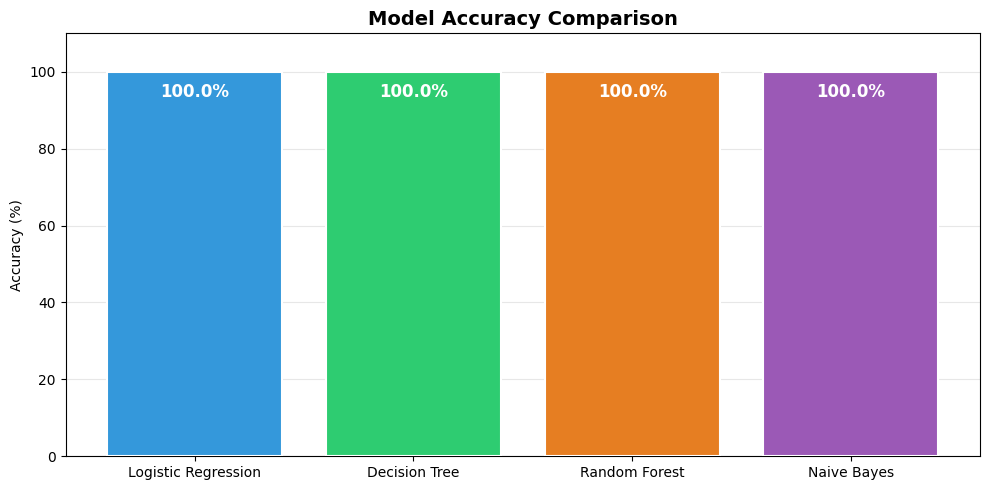

In [8]:
# Bar chart: Model Accuracy Comparison
plt.figure(figsize=(10, 5))
bar_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = plt.bar(results_df['Model'], results_df['Accuracy'] * 100,
               color=bar_colors, edgecolor='white', linewidth=1.5, zorder=3)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f"{bar.get_height():.1f}%", ha='center', va='top',
             fontsize=12, fontweight='bold', color='white')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(alpha=0.3, axis='y', zorder=0)
plt.tight_layout()
plt.show()

## Step 7 — Confusion Matrix (Best Model)

 Best Model: Logistic Regression (100.0% accuracy)

 Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         5
        Pass       1.00      1.00      1.00         7

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



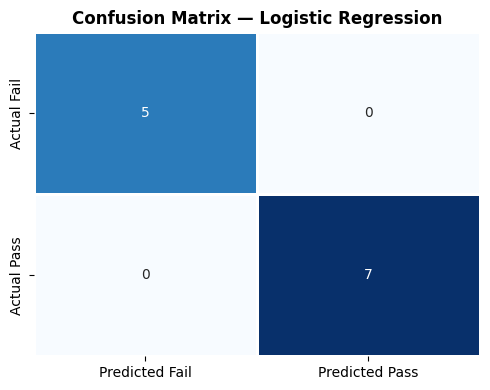

  True Positives  (TP) = 7  → Correctly predicted Pass
  True Negatives  (TN) = 5  → Correctly predicted Fail
  False Positives (FP) = 0  → Predicted Pass, Actually Fail
  False Negatives (FN) = 0  → Predicted Fail, Actually Pass


In [22]:
# Pick best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f" Best Model: {best_model_name} ({results_df.iloc[0]['Accuracy']*100:.1f}% accuracy)")
print()
print(" Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Fail', 'Pass']))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'],
            linewidths=1, linecolor='white', cbar=False)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  (TP) = {tp}  → Correctly predicted Pass")
print(f"  True Negatives  (TN) = {tn}  → Correctly predicted Fail")
print(f"  False Positives (FP) = {fp}  → Predicted Pass, Actually Fail")
print(f"  False Negatives (FN) = {fn}  → Predicted Fail, Actually Pass")

##  Step 8 — Predict on New Student Data

In [23]:
# ── Enter new student details here ────
new_students = pd.DataFrame({
    'Study_Hours'    : [6,   2,   4],
    'Attendance'     : [85,  45,  70],
    'Previous_Marks' : [78,  35,  60],
    'Assignments'    : [80,  30,  65],
    'Internal_Marks' : [75,  38,  62]
})

predictions = best_model.predict(new_students)
probabilities = best_model.predict_proba(new_students)

new_students['Predicted_Result'] = le.inverse_transform(predictions)
new_students['Pass_Probability_%'] = (probabilities[:, 1] * 100).round(1)
new_students['At_Risk'] = new_students['Predicted_Result'].apply(
    lambda x: ' YES' if x == 'Fail' else ' NO'
)

print(f"🔮 Predictions using: {best_model_name}")
print()
print(new_students.to_string(index=False))
print()
for i, row in new_students.iterrows():
    status = ' FAIL - At Risk!' if row['Predicted_Result'] == 'Fail' else ' PASS'
    print(f"  Student {i+1}: {status} (Pass probability: {row['Pass_Probability_%']}%)")

🔮 Predictions using: Logistic Regression

 Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks Predicted_Result  Pass_Probability_% At_Risk
           6          85              78           80              75             Pass               100.0      NO
           2          45              35           30              38             Fail                 0.0     YES
           4          70              60           65              62             Pass               100.0      NO

  Student 1:  PASS (Pass probability: 100.0%)
  Student 2:  FAIL - At Risk! (Pass probability: 0.0%)
  Student 3:  PASS (Pass probability: 100.0%)


       🎓 STUDENT PERFORMANCE PREDICTOR
 Study Hours per Day  (e.g. 5)       : 4
 Attendance Percentage (e.g. 75)     : 56
 Previous Exam Marks   (e.g. 68)     : 76
 Assignment Score      (e.g. 72)     : 55
 Internal Marks        (e.g. 65)     : 66

-------------------------------------------------------
  INPUT SUMMARY
-------------------------------------------------------
   Study Hours      : 4.0 hrs/day
   Attendance       : 56.0%
   Previous Marks   : 76.0
   Assignments      : 55.0
   Internal Marks   : 66.0
-------------------------------------------------------
   Model Used       : Logistic Regression
-------------------------------------------------------
    PREDICTION    : PASS
    Pass Probability : 100.0%
     Fail Probability : 0.0%

    Status: Excellent! Keep it up. 🌟


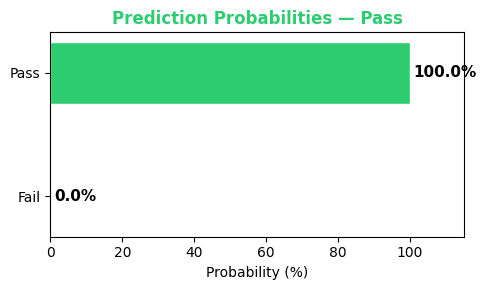

In [25]:
## Manual Input: Predict for a Single Student
print("=" * 55)
print("       🎓 STUDENT PERFORMANCE PREDICTOR")
print("=" * 55)

# ──   ENTER STUDENT DETAILS HERE ───
study_hours     = float(input(" Study Hours per Day  (e.g. 5)       : "))
attendance      = float(input(" Attendance Percentage (e.g. 75)     : "))
previous_marks  = float(input(" Previous Exam Marks   (e.g. 68)     : "))
assignments     = float(input(" Assignment Score      (e.g. 72)     : "))
internal_marks  = float(input(" Internal Marks        (e.g. 65)     : "))

# Build input DataFrame
student_input = pd.DataFrame({
    'Study_Hours'    : [study_hours],
    'Attendance'     : [attendance],
    'Previous_Marks' : [previous_marks],
    'Assignments'    : [assignments],
    'Internal_Marks' : [internal_marks]
})

# Predict using the best trained model
prediction  = best_model.predict(student_input)[0]
probability = best_model.predict_proba(student_input)[0]

result_label  = le.inverse_transform([prediction])[0]
pass_prob     = round(probability[1] * 100, 1)
fail_prob     = round(probability[0] * 100, 1)

# ── Display Result ───
print()
print("-" * 55)
print("  INPUT SUMMARY")
print("-" * 55)
print(f"   Study Hours      : {study_hours} hrs/day")
print(f"   Attendance       : {attendance}%")
print(f"   Previous Marks   : {previous_marks}")
print(f"   Assignments      : {assignments}")
print(f"   Internal Marks   : {internal_marks}")
print("-" * 55)
print(f"   Model Used       : {best_model_name}")
print("-" * 55)

if result_label == 'Pass':
    print(f"    PREDICTION    : PASS")
    print(f"    Pass Probability : {pass_prob}%")
    print(f"     Fail Probability : {fail_prob}%")
    print()
    if pass_prob >= 85:
        print("    Status: Excellent! Keep it up. 🌟")
    elif pass_prob >= 65:
        print("    Status: Good performance. Stay consistent.")
    else:
        print("   Status: Borderline pass — a bit more effort recommended.")
else:
    print(f"    PREDICTION    : FAIL   AT RISK")
    print(f"    Fail Probability : {fail_prob}%")
    print(f"    Pass Probability : {pass_prob}%")
    print()
    print("    Suggestions to improve:")
    if study_hours < 4:
        print("      •  Increase daily study hours (aim for at least 4–5 hrs)")
    if attendance < 70:
        print("      •   Improve attendance (target ≥ 75%)")
    if previous_marks < 55:
        print("      •   Focus on strengthening fundamentals from previous topics")
    if assignments < 55:
        print("      •   Complete pending assignments regularly")
    if internal_marks < 55:
        print("      •  Revise syllabus and attempt more internal practice tests")

print("=" * 55)

# ── Mini bar chart: Pass vs Fail probability ─────────────────
plt.figure(figsize=(5, 3))
bars = plt.barh(['Fail', 'Pass'], [fail_prob, pass_prob],
                color=['#e74c3c', '#2ecc71'], edgecolor='white', height=0.5)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height() / 2,
             f'{width:.1f}%', va='center', fontweight='bold', fontsize=11)
plt.xlim(0, 115)
plt.title(f'Prediction Probabilities — {result_label}',
          fontsize=12, fontweight='bold',
          color='#2ecc71' if result_label == 'Pass' else '#e74c3c')
plt.xlabel('Probability (%)')
plt.tight_layout()
plt.show()

## Step 9 — Identify All At-Risk Students

  Students Predicted to FAIL: 24 out of 60

Student_ID  Study_Hours  Attendance  Previous_Marks Final_Result  Pass_Probability_%
      S002            2          55              40         Fail                 0.0
      S004            1          40              35         Fail                 0.0
      S006            3          60              50         Fail                 4.5
      S009            2          48              42         Fail                 0.0
      S012            1          35              30         Fail                 0.0
      S014            3          52              45         Fail                 0.0
      S017            2          50              38         Fail                 0.0
      S019            1          42              32         Fail                 0.0
      S022            3          58              48         Fail                 0.3
      S024            2          46              36         Fail                 0.0
      S027           

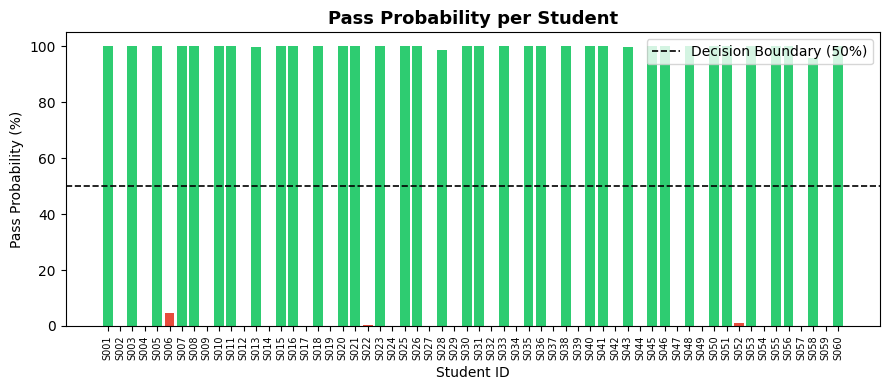

 Green = Predicted PASS  |   Red = Predicted FAIL (At Risk)


In [27]:
# Predict on full dataset
all_preds = best_model.predict(df[features])
all_probs = best_model.predict_proba(df[features])

df['Predicted_Result']    = le.inverse_transform(all_preds)
df['Pass_Probability_%']  = (all_probs[:, 1] * 100).round(1)

at_risk = df[df['Predicted_Result'] == 'Fail'][[
    'Student_ID', 'Study_Hours', 'Attendance',
    'Previous_Marks', 'Final_Result', 'Pass_Probability_%'
]].reset_index(drop=True)

print(f"  Students Predicted to FAIL: {len(at_risk)} out of {len(df)}")
print()
print(at_risk.to_string(index=False))

# Visual summary
plt.figure(figsize=(9, 4))
colors_pred = df['Predicted_Result'].map({'Pass': '#2ecc71', 'Fail': '#e74c3c'})
plt.bar(df['Student_ID'], df['Pass_Probability_%'], color=colors_pred, edgecolor='none')
plt.axhline(50, color='black', linestyle='--', linewidth=1.2, label='Decision Boundary (50%)')
plt.title('Pass Probability per Student', fontsize=13, fontweight='bold')
plt.xlabel('Student ID')
plt.ylabel('Pass Probability (%)')
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()
print(" Green = Predicted PASS  |   Red = Predicted FAIL (At Risk)")

## Conclusion

| Module | Description |
|--------|-------------|
| Data Collection | 60 student records with 5 features |
| Preprocessing | Label encoding, null check, split 80/20 |
| EDA | Distribution, boxplots, scatter, heatmap |
| Models Trained | Logistic Regression, Decision Tree, Random Forest, Naive Bayes |
| Best Model | Selected automatically based on accuracy |
| Output | Pass/Fail prediction + At-risk student list |

**Future Enhancements:**
- Integration with a mobile app for real-time alerts
- Personalized AI-based learning recommendations
- Integration with LMS (Learning Management Systems)

---
*Minor Project — Student Performance Prediction System using Machine Learning*